# 1. Problem Framing

### Business Problem & Intended User
* **User & Decision:** This model is designed for a bank's **Credit Assessment Officer** to decide whether to approve or reject/flag a loan application from a credit applicant.
* **Target Variable:** `target`
  * `0`: Good / Creditworthy Applicant (Negative Class)
  * `1`: High Risk / Default Risk Applicant (**Positive Class**)

### Error Cost Analysis (False Positives vs. False Negatives)
* **False Positive (FP):** Predicting an applicant is High Risk (`1`) when they are actually Creditworthy (`0`).
  * *Cost:* The bank misses out on interest income and potentially alienates a good customer.
* **False Negative (FN):** Predicting an applicant is Creditworthy (`0`) when they are actually High Risk (`1`).
  * *Cost:* The bank issues a loan that defaults, resulting in a direct capital loss of the principal amount.
* **Verdict:** A **False Negative is significantly worse** than a False Positive because losing the full loan principal costs much more than losing the margin on interest income.

### Main Metric Selection
* **Primary Metric:** **Recall (Sensitivity)** on the positive class (`1`).
* **Justification:** Because False Negatives carry the highest financial risk, our priority is to maximize the proportion of actual defaults caught before approving loans. We will track Precision and F1-Score as secondary metrics to monitor the trade-off with missed business opportunities, but models will be selected and tuned primarily based on **Recall**.

# Step 1: Load Data & Prepare Setup

**What**: Downloads real bank credit data and translates original coding labels into standard computer numbers (0 = Good, 1 = High Risk).

**Why**: Computers cannot analyze raw files directly; downloading, organizing columns, and creating uniform numerical target labels gives the model a clear base to learn from.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, ConfusionMatrixDisplay

# Load real Statlog (German Credit Data) directly from UCI Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

col_names = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment_status', 'installment_rate', 'personal_status_sex',
    'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents', 'telephone',
    'foreign_worker', 'target'
]

# Load into DataFrame
df = pd.read_csv(url, sep=' ', names=col_names)

# Standardize target: original UCI data uses 1 (Good) and 2 (Bad/High Risk).
# Convert to standard binary labels: 0 (Good / Creditworthy) and 1 (Bad / High Risk)
df['target'] = df['target'].map({1: 0, 2: 1})

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Automatically group numerical and categorical feature names for your preprocessor
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Dataset successfully loaded directly from UCI!")
print(f"Total Rows: {len(df)} | Total Features: {X.shape[1]}")

Dataset successfully loaded directly from UCI!
Total Rows: 1000 | Total Features: 20


# Step 2: Split Data into Training and Testing Sets

**What**: Splits the full dataset into two parts: 80% for training the models and 20% held back for testing.

**Why**: Evaluating a model on the same data it learned from causes cheating (overfitting); keeping a separate test set ensures fair evaluation on unseen applicants.

In [ ]:
# ==========================================
# STEP 2: STRATIFIED SPLIT FIRST
# ==========================================
print("\n2/5 - Splitting dataset into train and test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)


2/5 - Splitting dataset into train and test...


# Step 3: Set Up Cleaning Pipeline & Dummy Baseline

**What**: Sets up automatic data formatting rules for numbers and text categories, then trains a basic "Dummy" model that guesses the most common result every time.

**Why**: Raw data comes in mixed formats that machine learning tools cannot read without formatting, and the simple baseline provides a minimum quality standard to beat.

In [ ]:
# ==========================================
# STEP 3: PREPROCESSING PIPELINE & BASELINE
# ==========================================
# Dynamically pull column types from the dataset
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# Mandatory Baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

# Step 4: Train & Tune Machine Learning Models

**What**: Trains three distinct models (KNN, Logistic Regression, Random Forest) using cross-validation to search for optimal mathematical settings.

**Why**: Testing multiple algorithms and tuning their settings identifies which approach catches risky bank applicants most effectively.


3/5 - Tuning models with 5-fold cross-validation...


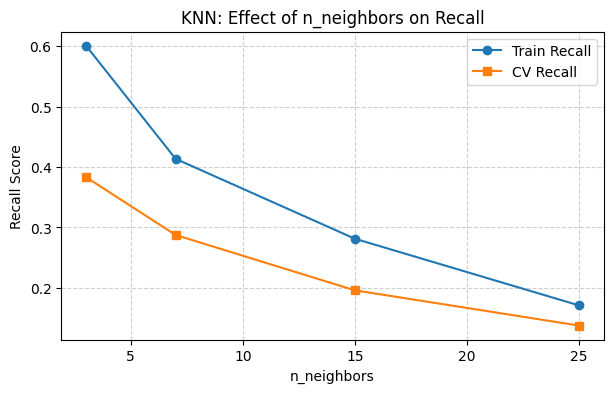

In [ ]:
# ==========================================
# STEP 4: MODEL TUNING (KNN, LOGISTIC REGRESSION, RANDOM FOREST)
# ==========================================
print("\n3/5 - Tuning models with 5-fold cross-validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 1. KNN
knn_pipe = Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier())])
grid_knn = GridSearchCV(
    knn_pipe,
    {'clf__n_neighbors': [3, 7, 15, 25]},
    cv=cv,
    scoring='recall',
    return_train_score=True
)
grid_knn.fit(X_train, y_train)


# 2. Logistic Regression
lr_pipe = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])
grid_lr = GridSearchCV(
    lr_pipe,
    {'clf__C': [0.01, 0.1, 1.0, 10.0]},
    cv=cv,
    scoring='recall',
    return_train_score=True
)
grid_lr.fit(X_train, y_train)


# 3. Random Forest
rf_pipe = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))])
grid_rf = GridSearchCV(
    rf_pipe,
    {'clf__n_estimators': [50, 100], 'clf__max_depth': [3, 6, None]},
    cv=cv,
    scoring='recall',
    return_train_score=True
)
grid_rf.fit(X_train, y_train)


# Plot KNN hyperparameter tuning
knn_results = pd.DataFrame(grid_knn.cv_results_)
plt.figure(figsize=(7, 4))
plt.plot(knn_results['param_clf__n_neighbors'], knn_results['mean_train_score'], label='Train Recall', marker='o')
plt.plot(knn_results['param_clf__n_neighbors'], knn_results['mean_test_score'], label='CV Recall', marker='s')
plt.title("KNN: Effect of n_neighbors on Recall")
plt.xlabel("n_neighbors")
plt.ylabel("Recall Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Step 5: Evaluate Models on Unseen Data

**What**: Runs all trained models against the 20% test set, generates a comparison performance table, and plots visual confusion matrices.

**Why**: Direct metrics and matrix charts show exactly how many risky applicants each model accurately flagged versus missed in practice.


4/5 - Evaluating on unseen test set...


,Model,Best Parameters,Train Recall,CV Recall,Test Recall (Defaults Caught),Test Precision,Test F1-Score
0,Baseline (Dummy),strategy='most_frequent',0.000,N/A,0.000,0.000,0.000
1,KNN,{'clf__n_neighbors': 3},0.601,0.383 ± 0.036,0.350,0.429,0.385
2,Logistic Regression,{'clf__C': 0.1},0.768,0.696 ± 0.080,0.767,0.517,0.617
3,Random Forest,"{'clf__max_depth': 3, 'clf__n_estimators': 100}",0.810,0.754 ± 0.073,0.717,0.478,0.573


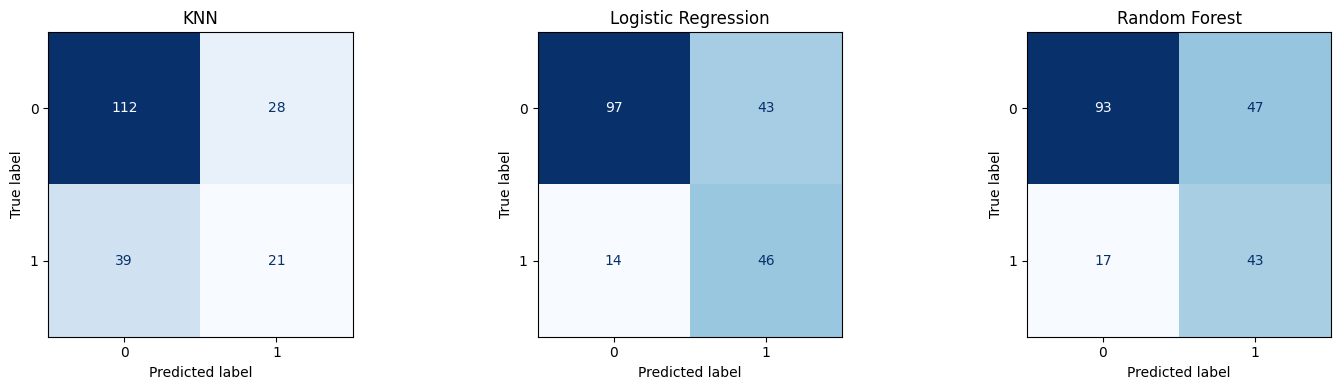

In [ ]:
# ==========================================
# STEP 5: COMPARISON TABLE & CONFUSION MATRICES
# ==========================================
print("\n4/5 - Evaluating on unseen test set...")
models = {
    "Baseline (Dummy)": dummy,
    "KNN": grid_knn.best_estimator_,
    "Logistic Regression": grid_lr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_
}


records = []
for name, model in models.items():
    if name == "Baseline (Dummy)":
        cv_score = "N/A"
        train_score = "0.000"
        best_params = "strategy='most_frequent'"
    else:
        grid = {"KNN": grid_knn, "Logistic Regression": grid_lr, "Random Forest": grid_rf}[name]
        mean_cv = grid.cv_results_['mean_test_score'][grid.best_index_]
        std_cv = grid.cv_results_['std_test_score'][grid.best_index_]
        mean_tr = grid.cv_results_['mean_train_score'][grid.best_index_]
        cv_score = f"{mean_cv:.3f} ± {std_cv:.3f}"
        train_score = f"{mean_tr:.3f}"
        best_params = str(grid.best_params_)


    y_pred = model.predict(X_test)
    records.append({
        "Model": name,
        "Best Parameters": best_params,
        "Train Recall": train_score,
        "CV Recall": cv_score,
        "Test Recall (Defaults Caught)": f"{recall_score(y_test, y_pred, zero_division=0):.3f}",
        "Test Precision": f"{precision_score(y_test, y_pred, zero_division=0):.3f}",
        "Test F1-Score": f"{f1_score(y_test, y_pred, zero_division=0):.3f}"
    })


comparison_table = pd.DataFrame(records)
display(comparison_table)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, list(models.items())[1:]):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}")
plt.tight_layout()
plt.show()




### Step 6: Error Analysis & Fairness Check

**What are we doing?**
We are looking closely at the mistakes our best model (Logistic Regression) made on the test data. We are checking:
1. **False Negatives:** Risky applicants the model incorrectly labeled as safe.
2. **False Positives:** Safe applicants the model incorrectly labeled as risky.
3. **Subgroup Fairness:** How accurately the model performs across different age groups and demographic backgrounds (such as personal status and gender).

**Why are we doing this?**
- **To prevent costly mistakes:** In credit lending, missing a high-risk applicant (False Negative) costs the bank far more money than accidentally flagging a good applicant for manual review (False Positive).
- **To ensure fairness:** We want to make sure our automated model doesn't unfairly penalize younger applicants or specific demographic groups simply because they have shorter credit histories.

In [ ]:
# ==========================================\n
# STEP 6: LOOK AT THE ERRORS & SUBGROUP ANALYSIS
# ==========================================\n
print("\n--- ERROR ANALYSIS ---")

# 1. Extract Test Set Predictions from the Best Model (Logistic Regression)
best_model = grid_lr.best_estimator_
y_pred_test = best_model.predict(X_test)

# Combine test data, actual labels, and predictions into a single DataFrame
test_analysis_df = X_test.copy()
test_analysis_df['actual'] = y_test
test_analysis_df['predicted'] = y_pred_test
test_analysis_df['is_error'] = test_analysis_df['actual'] != test_analysis_df['predicted']
test_analysis_df['error_type'] = 'Correct'
test_analysis_df.loc[(test_analysis_df['actual'] == 1) & (test_analysis_df['predicted'] == 0), 'error_type'] = 'False Negative (Dangerous)'
test_analysis_df.loc[(test_analysis_df['actual'] == 0) & (test_analysis_df['predicted'] == 1), 'error_type'] = 'False Positive (Lost Business)'

print(f"Total Test Cases: {len(test_analysis_df)}")
print(f"Total Misclassifications: {test_analysis_df['is_error'].sum()}")
print(test_analysis_df['error_type'].value_counts())

# 2. Inspect Specific Misclassified Cases (False Negatives)
print("\nSample False Negatives (High Risk Applicants Missed by the Model):")
display(test_analysis_df[test_analysis_df['error_type'] == 'False Negative (Dangerous)'][['checking_status', 'duration', 'credit_amount', 'savings', 'age', 'personal_status_sex']].head())

# 3. Subgroup Performance Breakdown
print("\n--- SUBGROUP PERFORMANCE ANALYSIS ---")

# Group 1: Personal Status & Sex
print("\n1. Performance by Personal Status & Sex:")
sex_group = test_analysis_df.groupby('personal_status_sex').apply(
    lambda g: pd.Series({
        'Total Cases': len(g),
        'Actual Defaults': (g['actual'] == 1).sum(),
        'Recall (Defaults Caught)': recall_score(g['actual'], g['predicted'], zero_division=0),
        'Precision': precision_score(g['actual'], g['predicted'], zero_division=0)
    })
).reset_index()
display(sex_group)

# Group 2: Age Band
test_analysis_df['age_group'] = pd.cut(test_analysis_df['age'], bins=[0, 25, 40, 60, 100], labels=['<25', '25-40', '40-60', '60+'])
print("\n2. Performance by Age Group:")
age_group = test_analysis_df.groupby('age_group', observed=False).apply(
    lambda g: pd.Series({
        'Total Cases': len(g),
        'Actual Defaults': (g['actual'] == 1).sum(),
        'Recall (Defaults Caught)': recall_score(g['actual'], g['predicted'], zero_division=0),
        'Precision': precision_score(g['actual'], g['predicted'], zero_division=0)
    })
).reset_index()
display(age_group)


--- ERROR ANALYSIS ---
Total Test Cases: 200
Total Misclassifications: 57
error_type
Correct                           143
False Positive (Lost Business)     43
False Negative (Dangerous)         14
Name: count, dtype: int64

Sample False Negatives (High Risk Applicants Missed by the Model):


,checking_status,duration,credit_amount,savings,age,personal_status_sex
966,A12,27,2520,A63,23,A93
668,A11,12,4843,A61,43,A93
412,A14,12,2292,A61,42,A93
435,A12,12,1484,A65,25,A94
796,A11,18,7511,A65,51,A93



--- SUBGROUP PERFORMANCE ANALYSIS ---

1. Performance by Personal Status & Sex:


/tmp/ipykernel_5046/938182333.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sex_group = test_analysis_df.groupby('personal_status_sex').apply(


,personal_status_sex,Total Cases,Actual Defaults,Recall (Defaults Caught),Precision
0,A91,9.0,3.0,1.000000,0.500000
1,A92,61.0,20.0,0.900000,0.529412
2,A93,118.0,34.0,0.676471,0.522727
3,A94,12.0,3.0,0.666667,0.400000



2. Performance by Age Group:


/tmp/ipykernel_5046/938182333.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_group = test_analysis_df.groupby('age_group', observed=False).apply(


,age_group,Total Cases,Actual Defaults,Recall (Defaults Caught),Precision
0,<25,44.0,20.0,0.800000,0.592593
1,25-40,92.0,27.0,0.851852,0.560976
2,40-60,51.0,12.0,0.500000,0.375000
3,60+,13.0,1.0,1.000000,0.200000


# Step 7: Make Live Risk Predictions

**What**: Feeds a single applicant profile into the top-performing model to output a default probability score and loan decision.

**Why**: Demonstrates how the trained machine learning pipeline translates abstract risk calculations into real-world lending decisions for bank officers.

In [ ]:
# ==========================================
# STEP 7: LIVE PREDICTION (USE IT)
# ==========================================
print("\n5/5 - Testing live prediction on a new case...")
best_model = grid_lr.best_estimator_

# Sample applicant with valid German Credit dataset values
sample_applicant = pd.DataFrame([{
    'checking_status': 'A11',      # < 0 DM
    'duration': 36,                 # 36 months
    'credit_history': 'A32',        # existing credits paid back duly
    'purpose': 'A41',               # car (used)
    'credit_amount': 7500,          # 7,500 DM
    'savings': 'A61',               # < 100 DM
    'employment_status': 'A72',     # < 1 year
    'installment_rate': 4,          # 4% of disposable income
    'personal_status_sex': 'A93',   # male: single
    'other_debtors': 'A101',        # none
    'residence_since': 2,           # 2 years
    'property': 'A121',             # real estate
    'age': 22,                      # 22 years old
    'other_installment_plans': 'A143', # none
    'housing': 'A151',              # rent
    'existing_credits': 1,          # 1 credit
    'job': 'A173',                  # skilled employee
    'num_dependents': 1,            # 1 dependent
    'telephone': 'A191',            # none
    'foreign_worker': 'A201'        # yes
}])

prediction = best_model.predict(sample_applicant)[0]
probability = best_model.predict_proba(sample_applicant)[0, 1]

print("\n=== LIVE DECISION FOR CREDIT UNION OFFICER ===")
print(f"Recommended Action: {'FLAG FOR STRUCTURED REPAYMENT (High Risk)' if prediction == 1 else 'AUTOMATIC APPROVAL'}")
print(f"Predicted Probability of Default: {probability * 100:.1f}%\n")


5/5 - Testing live prediction on a new case...

=== LIVE DECISION FOR CREDIT UNION OFFICER ===
Recommended Action: FLAG FOR STRUCTURED REPAYMENT (High Risk)
Predicted Probability of Default: 80.8%

